<a href="https://colab.research.google.com/github/kavyaayyappan1998/DATA266---2738/blob/main/GPU_Assignment1/02_hw2_5_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path
import json

def resolve_assignment_dir():
    cwd = Path.cwd().resolve()

    # Local/GPU-lab checkout.
    for p in [cwd, *cwd.parents]:
        if p.name == "GPU_Assignment1" or (p / "README_FIRST.md").exists():
            return p

    # Google Colab / Google Drive.
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        root = Path("/content/drive/MyDrive")
        matches = list(root.rglob("GPU_Assignment1"))
        if len(matches) == 1:
            return matches[0]
        if len(matches) > 1:
            raise RuntimeError(
                "Multiple GPU_Assignment1 folders found: "
                + ", ".join(str(x) for x in matches)
            )
    except (ImportError, NotImplementedError):
        # Gracefully handle environments like Docker where google.colab exists but drive.mount fails
        pass

    # Return current directory if running locally
    return cwd

ASSIGNMENT_DIR = resolve_assignment_dir()
ARTIFACT_DIR = ASSIGNMENT_DIR / "hw2_5_artifacts"
PARAM_FILE = ARTIFACT_DIR / "student_params.json"

if not PARAM_FILE.exists():
    raise FileNotFoundError(f"student_params.json not found at: {PARAM_FILE}")

PARAMS = json.loads(PARAM_FILE.read_text())
SID4 = PARAMS["SID4"]
SEED = PARAMS["SEED"]
SLICE = PARAMS["SLICE"]
HP_ID = PARAMS["HP_ID"]
CLS_A = PARAMS["CLS_A"]
CLS_B = PARAMS["CLS_B"]

print("Loaded:", PARAM_FILE)


Loaded: /content/hw2_5_artifacts/student_params.json


Part D: The cost of attention

In [ ]:
import os, sys, gc, math, time, json, random, traceback, subprocess, platform, re
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

FIG_DIR = ARTIFACT_DIR / "figures"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
RUN_LOG = ARTIFACT_DIR / "RUN_LOG.txt"

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def log(message=""):
    line = str(message)
    print(line)
    with RUN_LOG.open("a", encoding="utf-8") as f:
        f.write(f"[{utc_now()}] {line}\n")

def log_exception(prefix, exc):
    tb = traceback.format_exc()
    log(f"{prefix}: {type(exc).__name__}: {exc}")
    with RUN_LOG.open("a", encoding="utf-8") as f:
        f.write(tb + "\n")

def run_cmd(cmd, check=False):
    p = subprocess.run(cmd, capture_output=True, text=True)
    if check and p.returncode != 0:
        raise RuntimeError(
            f"Command failed: {cmd}\nSTDOUT:\n{p.stdout}\nSTDERR:\n{p.stderr}"
        )
    return p

GPU_INFO_FILE = ARTIFACT_DIR / "gpu_info.json"
if not GPU_INFO_FILE.exists():
    raise FileNotFoundError("gpu_info.json missing. Run notebook 00 first.")

GPU_INFO = json.loads(GPU_INFO_FILE.read_text())
GPU_UUID = GPU_INFO["uuid"]
GPU_NAME = GPU_INFO["name"]
GPU_INDEX = int(GPU_INFO["nvidia_smi_index"])
CARD_SPECS = GPU_INFO["card_specs"]

if not GPU_INFO.get("hw25_supported_gpu", False):
    raise RuntimeError("Notebook 00 did not record an approved RTX 4090/5090 GPU.")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available.")

current = run_cmd([
    "nvidia-smi",
    "--query-gpu=index,name,uuid",
    "--format=csv,noheader,nounits"
], check=True)
current_rows = [[x.strip() for x in line.split(",")] for line in current.stdout.strip().splitlines()]
if not any(len(r) == 3 and r[2] == GPU_UUID for r in current_rows):
    raise RuntimeError(
        "The current GPU UUID does not match notebook 00. "
        "Rerun notebook 00 on this reserved GPU."
    )

DEVICE = torch.device("cuda:0")
torch.cuda.set_device(DEVICE)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

log("=" * 88)
log(
    f"Notebook started | GPU={GPU_NAME} | UUID={GPU_UUID} | "
    f"Driver CUDA={GPU_INFO.get('driver_cuda_version')} | "
    f"PyTorch CUDA build={torch.version.cuda}"
)


Notebook started | GPU=NVIDIA GeForce RTX 5090 | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | Driver CUDA=not parsed | PyTorch CUDA build=12.8


In [ ]:
import contextlib
import torch.nn.functional as F

BATCH = 4
HEADS = 32
HEAD_DIM = 64
DTYPE = torch.float16
COARSE_LENGTHS = [512, 1024, 2048, 4096, 8192, 16384]

# Boundary-search granularity. We explicitly report this resolution.
NAIVE_SEARCH_STEP = 512
FUSED_SEARCH_STEP = 8192
MAX_FUSED_SEARCH = 65536

def make_qkv(s):
    shape = (BATCH, HEADS, s, HEAD_DIM)
    q = torch.randn(shape, device=DEVICE, dtype=DTYPE)
    k = torch.randn(shape, device=DEVICE, dtype=DTYPE)
    v = torch.randn(shape, device=DEVICE, dtype=DTYPE)
    return q, k, v

def naive_attention(q, k, v):
    scale = 1.0 / math.sqrt(q.shape[-1])
    scores = torch.matmul(q, k.transpose(-2, -1)) * scale
    probs = torch.softmax(scores, dim=-1)
    out = torch.matmul(probs, v)
    return out

# Select a truly fused or memory-efficient backend; do not silently fall back to math SDPA.
def probe_fused_backend():
    q, k, v = make_qkv(512)
    errors = []

    # Newer PyTorch API.
    try:
        from torch.nn.attention import sdpa_kernel, SDPBackend
        candidates = [
            ("FLASH_ATTENTION", SDPBackend.FLASH_ATTENTION),
            ("EFFICIENT_ATTENTION", SDPBackend.EFFICIENT_ATTENTION),
        ]
        for label, backend in candidates:
            try:
                with sdpa_kernel(backend):
                    out = F.scaled_dot_product_attention(q, k, v, dropout_p=0.0, is_causal=False)
                torch.cuda.synchronize()
                del out, q, k, v
                gc.collect(); torch.cuda.empty_cache()
                return ("torch.nn.attention." + label, ("new", backend), errors)
            except Exception as exc:
                errors.append(f"{label}: {type(exc).__name__}: {exc}")
    except Exception as exc:
        errors.append(f"New sdpa_kernel API unavailable: {type(exc).__name__}: {exc}")

    # Legacy PyTorch CUDA SDPA controls.
    for label, kwargs in [
        ("legacy_flash", dict(enable_flash=True, enable_math=False, enable_mem_efficient=False)),
        ("legacy_mem_efficient", dict(enable_flash=False, enable_math=False, enable_mem_efficient=True)),
    ]:
        try:
            q, k, v = make_qkv(512)
            with torch.backends.cuda.sdp_kernel(**kwargs):
                out = F.scaled_dot_product_attention(q, k, v, dropout_p=0.0, is_causal=False)
            torch.cuda.synchronize()
            del out, q, k, v
            gc.collect(); torch.cuda.empty_cache()
            return (label, ("legacy", kwargs), errors)
        except Exception as exc:
            errors.append(f"{label}: {type(exc).__name__}: {exc}")

    try:
        del q, k, v
    except Exception:
        pass
    gc.collect(); torch.cuda.empty_cache()
    return (None, None, errors)

FUSED_BACKEND_NAME, FUSED_BACKEND_CONFIG, FUSED_PROBE_ERRORS = probe_fused_backend()
if FUSED_BACKEND_NAME is None:
    for e in FUSED_PROBE_ERRORS:
        log(e)
    raise RuntimeError(
        "No fused or memory-efficient SDPA backend is exposed. "
        "Do not use math SDPA for Part D. Update/install a CUDA-enabled PyTorch stack."
    )

log(f"Part D fused backend selected: {FUSED_BACKEND_NAME}")
for e in FUSED_PROBE_ERRORS:
    log("Backend probe note: " + e)

@contextlib.contextmanager
def fused_context():
    kind, cfg = FUSED_BACKEND_CONFIG
    if kind == "new":
        from torch.nn.attention import sdpa_kernel
        with sdpa_kernel(cfg):
            yield
    else:
        with torch.backends.cuda.sdp_kernel(**cfg):
            yield

def fused_attention(q, k, v):
    with fused_context():
        return F.scaled_dot_product_attention(q, k, v, dropout_p=0.0, is_causal=False)

Part D fused backend selected: torch.nn.attention.FLASH_ATTENTION


Measurement helper

In [ ]:
def measure_attention(s, impl_name, fn, latency_reps=3, do_warmup=True):
    q = k = v = out = None
    try:
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        q, k, v = make_qkv(s)
        torch.cuda.synchronize()

        if do_warmup:
            with torch.inference_mode():
                out = fn(q, k, v)
            torch.cuda.synchronize()
            del out
            out = None

        torch.cuda.reset_peak_memory_stats()

        times = []
        with torch.inference_mode():
            for _ in range(latency_reps):
                start = torch.cuda.Event(enable_timing=True)
                end = torch.cuda.Event(enable_timing=True)
                start.record()
                out = fn(q, k, v)
                end.record()
                end.synchronize()
                times.append(float(start.elapsed_time(end)))
                del out
                out = None

        peak_bytes = int(torch.cuda.max_memory_allocated())
        result = {
            "uuid": GPU_UUID,
            "gpu": GPU_NAME,
            "implementation": impl_name,
            "batch": BATCH,
            "heads": HEADS,
            "head_dim": HEAD_DIM,
            "dtype": str(DTYPE),
            "sequence_length": int(s),
            "success": True,
            "latency_reps": latency_reps,
            "median_latency_ms": float(np.median(times)),
            "mean_latency_ms": float(np.mean(times)),
            "peak_memory_bytes": peak_bytes,
            "peak_memory_GiB": peak_bytes / 1024**3,
            "error": ""
        }
        log(
            f"Part D | UUID={GPU_UUID} | {impl_name} | S={s} | SUCCESS | "
            f"latency={result['median_latency_ms']:.4f} ms | peak={result['peak_memory_GiB']:.4f} GiB"
        )
        return result

    except (torch.cuda.OutOfMemoryError, RuntimeError) as exc:
        text = str(exc).lower()
        is_oom = isinstance(exc, torch.cuda.OutOfMemoryError) or "out of memory" in text
        if not is_oom:
            raise
        result = {
            "uuid": GPU_UUID,
            "gpu": GPU_NAME,
            "implementation": impl_name,
            "batch": BATCH,
            "heads": HEADS,
            "head_dim": HEAD_DIM,
            "dtype": str(DTYPE),
            "sequence_length": int(s),
            "success": False,
            "latency_reps": latency_reps,
            "median_latency_ms": np.nan,
            "mean_latency_ms": np.nan,
            "peak_memory_bytes": np.nan,
            "peak_memory_GiB": np.nan,
            "error": f"{type(exc).__name__}: {exc}"
        }
        log(
            f"Part D | UUID={GPU_UUID} | {impl_name} | S={s} | OOM/FAIL | "
            f"{type(exc).__name__}: {str(exc).splitlines()[0]}"
        )
        return result
    finally:
        try:
            del q, k, v, out
        except Exception:
            pass
        gc.collect()
        torch.cuda.empty_cache()

def reps_for_s(s):
    if s <= 2048:
        return 5
    if s <= 4096:
        return 3
    if s <= 16384:
        return 2
    return 1

Part D.1–D.2 — coarse naive sweep

In [ ]:
naive_rows = []
for s in COARSE_LENGTHS:
    naive_rows.append(
        measure_attention(s, "naive", naive_attention, latency_reps=reps_for_s(s), do_warmup=True)
    )

naive_coarse = pd.DataFrame(naive_rows)
naive_coarse.to_csv(ARTIFACT_DIR / "part_d_naive_coarse.csv", index=False)
display(naive_coarse)

Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | naive | S=512 | SUCCESS | latency=0.3713 ms | peak=0.1642 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | naive | S=1024 | SUCCESS | latency=1.1396 ms | peak=0.5704 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | naive | S=2048 | SUCCESS | latency=4.8905 ms | peak=2.1329 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | naive | S=4096 | SUCCESS | latency=20.2454 ms | peak=8.2579 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | naive | S=8192 | SUCCESS | latency=343.7661 ms | peak=32.5079 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | naive | S=16384 | OOM/FAIL | OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 GiB. GPU 0 has a total capacity of 31.84 GiB of which 0 bytes is free. Process 2054 has 17179869184.00 GiB memory in use. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 64.76 GiB is allocated

,uuid,gpu,implementation,batch,heads,head_dim,dtype,sequence_length,success,latency_reps,median_latency_ms,mean_latency_ms,peak_memory_bytes,peak_memory_GiB,error
0,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,naive,4,32,64,torch.float16,512,True,5,0.371264,14.718771,1.762918e+08,0.164185,
1,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,naive,4,32,64,torch.float16,1024,True,5,1.139552,1.199174,6.124995e+08,0.570435,
2,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,naive,4,32,64,torch.float16,2048,True,5,4.890464,4.859085,2.290221e+09,2.132935,
3,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,naive,4,32,64,torch.float16,4096,True,3,20.245407,20.263957,8.866890e+09,8.257935,
4,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,naive,4,32,64,torch.float16,8192,True,2,343.766052,343.766052,3.490513e+10,32.507935,
5,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,naive,4,32,64,torch.float16,16384,False,2,NaN,NaN,NaN,NaN,OutOfMemoryError: CUDA out of memory. Tried to...


Part D.3 — refine the naive OOM boundary

In [ ]:
import gc
import torch
import pandas as pd

def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()

def refine_boundary(fn, impl_name, existing_df, step, max_search):
    tested = {}
    for _, r in existing_df.iterrows():
        tested[int(r["sequence_length"])] = bool(r["success"])

    successes = sorted([s for s, ok in tested.items() if ok])
    failures = sorted([s for s, ok in tested.items() if not ok])

    if not successes:
        return {"largest_success": None, "smallest_failure": min(failures) if failures else None,
                "step": step, "status": "no successful tested length"}, pd.DataFrame()

    lo = max(successes)

    # Find the first tested failure above lo, or expand exponentially.
    above_failures = [s for s in failures if s > lo]
    if above_failures:
        hi = min(above_failures)
    else:
        hi = lo * 2
        extra_rows = []
        while hi <= max_search:
            clear_gpu()
            r = measure_attention(hi, impl_name, fn, latency_reps=1, do_warmup=False)
            extra_rows.append(r)
            tested[hi] = bool(r["success"])
            if not r["success"]:
                break
            lo = hi
            hi *= 2
        if hi > max_search and (not extra_rows or extra_rows[-1]["success"]):
            boundary = {
                "largest_success": lo,
                "smallest_failure": None,
                "step": step,
                "status": f"no failure observed through search cap {max_search}"
            }
            return boundary, pd.DataFrame(extra_rows)
        expansion_df = pd.DataFrame(extra_rows)

    # Align binary probes to the requested resolution.
    refine_rows = []
    while hi - lo > step:
        raw_mid = (lo + hi) // 2
        mid = (raw_mid // step) * step
        if mid <= lo:
            mid = lo + step
        if mid >= hi:
            break

        if mid in tested:
            ok = tested[mid]
        else:
            clear_gpu()
            r = measure_attention(mid, impl_name, fn, latency_reps=1, do_warmup=False)
            refine_rows.append(r)
            ok = bool(r["success"])
            tested[mid] = ok

        if ok:
            lo = mid
        else:
            hi = mid

    rows = []
    if 'expansion_df' in locals() and not expansion_df.empty:
        rows.extend(expansion_df.to_dict("records"))
    rows.extend(refine_rows)

    boundary = {
        "largest_success": int(lo),
        "smallest_failure": int(hi),
        "step": int(step),
        "status": "bracketed"
    }
    return boundary, pd.DataFrame(rows)

clear_gpu()
naive_boundary, naive_refine = refine_boundary(
    naive_attention, "naive", naive_coarse, NAIVE_SEARCH_STEP, max_search=65536
)
naive_refine.to_csv(ARTIFACT_DIR / "part_d_naive_boundary_tests.csv", index=False)
log(f"Naive OOM boundary result: {naive_boundary}")
display(pd.DataFrame([naive_boundary]))
if not naive_refine.empty:
    display(naive_refine)

Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | naive | S=12288 | SUCCESS | latency=17596.4980 ms | peak=72.7579 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | naive | S=14336 | OOM/FAIL | OutOfMemoryError: CUDA out of memory. Tried to allocate 49.00 GiB. GPU 0 has a total capacity of 31.84 GiB of which 0 bytes is free. Process 2054 has 17179869184.00 GiB memory in use. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 49.66 GiB is allocated by PyTorch, and 11.88 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | naive | S=13312 | OOM/FAIL | OutOfMemoryError: CUDA out of memory. Tried t

,largest_success,smallest_failure,step,status
0,12288,12800,512,bracketed


,uuid,gpu,implementation,batch,heads,head_dim,dtype,sequence_length,success,latency_reps,median_latency_ms,mean_latency_ms,peak_memory_bytes,peak_memory_GiB,error
0,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,naive,4,32,64,torch.float16,12288,True,1,17596.498047,17596.498047,7.812324e+10,72.757935,
1,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,naive,4,32,64,torch.float16,14336,False,1,NaN,NaN,NaN,NaN,OutOfMemoryError: CUDA out of memory. Tried to...
2,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,naive,4,32,64,torch.float16,13312,False,1,NaN,NaN,NaN,NaN,OutOfMemoryError: CUDA out of memory. Tried to...
3,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,naive,4,32,64,torch.float16,12800,False,1,NaN,NaN,NaN,NaN,OutOfMemoryError: CUDA out of memory. Tried to...


Part D.4 — memory-vs-sequence fit

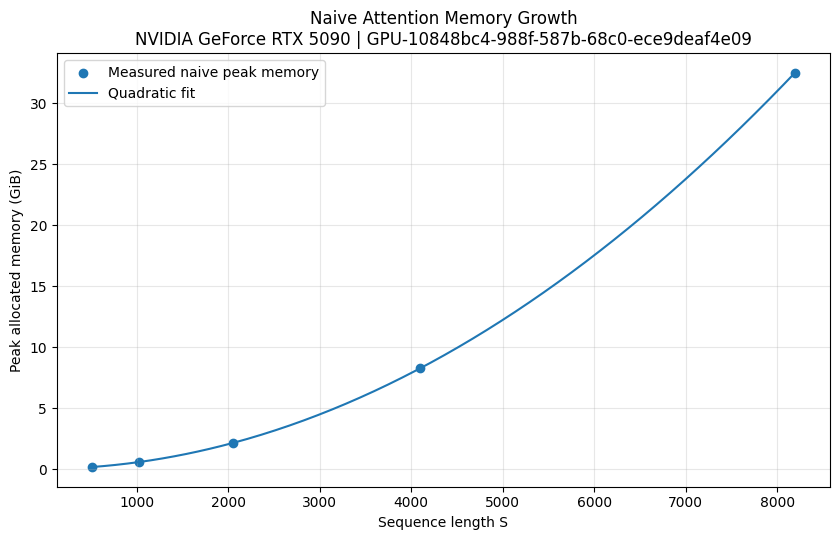

Part D quadratic fit: memory_GiB = 4.768371582031e-07*S^2 + 6.103515625000e-05*S + 7.934570e-03
Part D S^2 coefficient check | measured=4.768371582031e-07 | theory=4.768371582031e-07 GiB/token^2 | ratio=1.000000 | error=0.000%
The S^2 coefficient is compared directly with the closed-form cost of holding the score and softmax matrices simultaneously.


In [ ]:
naive_ok = naive_coarse[naive_coarse["success"] == True].copy()
if len(naive_ok) < 3:
    raise RuntimeError("Need at least 3 successful naive sequence lengths to fit a quadratic.")

x = naive_ok["sequence_length"].to_numpy(dtype=float)
y = naive_ok["peak_memory_GiB"].to_numpy(dtype=float)
coef = np.polyfit(x, y, deg=2)
a2, b1, c0 = [float(v) for v in coef]

# Closed-form S^2 coefficient for the two simultaneously-live B*H*S*S
# FP16 intermediates: scores + softmax probabilities.
dtype_bytes = torch.empty((), dtype=DTYPE).element_size()
theory_a2 = (2.0 * BATCH * HEADS * dtype_bytes) / (1024.0**3)
a2_ratio = a2 / theory_a2
a2_error_pct = 100.0 * (a2 - theory_a2) / theory_a2

fit_x = np.linspace(x.min(), x.max(), 300)
fit_y = np.polyval(coef, fit_x)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(x, y, label="Measured naive peak memory")
ax.plot(fit_x, fit_y, label="Quadratic fit")
ax.set_xlabel("Sequence length S")
ax.set_ylabel("Peak allocated memory (GiB)")
ax.set_title(f"Naive Attention Memory Growth\n{GPU_NAME} | {GPU_UUID}")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

p = FIG_DIR / "part_d_naive_memory_quadratic_fit.png"
fig.savefig(p, dpi=180)
plt.show()

fit_info = {
    "uuid": GPU_UUID,
    "quadratic_coefficient_GiB_per_token2": a2,
    "theoretical_quadratic_coefficient_GiB_per_token2": theory_a2,
    "quadratic_coefficient_ratio_measured_to_theory": a2_ratio,
    "quadratic_coefficient_error_pct": a2_error_pct,
    "linear_coefficient_GiB_per_token": b1,
    "intercept_GiB": c0,
    "fit_expression": f"memory_GiB = {a2:.12e}*S^2 + {b1:.12e}*S + {c0:.6e}",
    "theory_expression": "2 * B * H * sizeof(dtype) / 2^30",
}
(ARTIFACT_DIR / "part_d_quadratic_fit.json").write_text(json.dumps(fit_info, indent=2))

log("Part D quadratic fit: " + fit_info["fit_expression"])
log(
    f"Part D S^2 coefficient check | measured={a2:.12e} | "
    f"theory={theory_a2:.12e} GiB/token^2 | "
    f"ratio={a2_ratio:.6f} | error={a2_error_pct:.3f}%"
)
log(
    "The S^2 coefficient is compared directly with the closed-form cost of "
    "holding the score and softmax matrices simultaneously."
)


Part D.5 — fused / memory-efficient attention

In [ ]:
fused_rows = []
for s in COARSE_LENGTHS:
    fused_rows.append(
        measure_attention(
            s, f"fused:{FUSED_BACKEND_NAME}", fused_attention,
            latency_reps=reps_for_s(s), do_warmup=True
        )
    )

fused_coarse = pd.DataFrame(fused_rows)
fused_coarse.to_csv(ARTIFACT_DIR / "part_d_fused_coarse.csv", index=False)
display(fused_coarse)

fused_boundary, fused_refine = refine_boundary(
    fused_attention, f"fused:{FUSED_BACKEND_NAME}", fused_coarse,
    FUSED_SEARCH_STEP, MAX_FUSED_SEARCH
)
fused_refine.to_csv(ARTIFACT_DIR / "part_d_fused_boundary_tests.csv", index=False)
log(f"Fused OOM boundary result: {fused_boundary}")
display(pd.DataFrame([fused_boundary]))
if not fused_refine.empty:
    display(fused_refine)

Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | fused:torch.nn.attention.FLASH_ATTENTION | S=512 | SUCCESS | latency=0.1295 ms | peak=0.0394 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | fused:torch.nn.attention.FLASH_ATTENTION | S=1024 | SUCCESS | latency=0.2567 ms | peak=0.0709 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | fused:torch.nn.attention.FLASH_ATTENTION | S=2048 | SUCCESS | latency=1.9663 ms | peak=0.1339 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | fused:torch.nn.attention.FLASH_ATTENTION | S=4096 | SUCCESS | latency=32.0238 ms | peak=0.2599 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | fused:torch.nn.attention.FLASH_ATTENTION | S=8192 | SUCCESS | latency=9.8758 ms | peak=0.5118 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | fused:torch.nn.attention.FLASH_ATTENTION | S=16384 | SUCCESS | latency=39.5258 ms | peak=1.0157 GiB


,uuid,gpu,implementation,batch,heads,head_dim,dtype,sequence_length,success,latency_reps,median_latency_ms,mean_latency_ms,peak_memory_bytes,peak_memory_GiB,error
0,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,fused:torch.nn.attention.FLASH_ATTENTION,4,32,64,torch.float16,512,True,5,0.129504,0.148966,42337280,0.039430,
1,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,fused:torch.nn.attention.FLASH_ATTENTION,4,32,64,torch.float16,1024,True,5,0.256672,2.266266,76153856,0.070924,
2,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,fused:torch.nn.attention.FLASH_ATTENTION,4,32,64,torch.float16,2048,True,5,1.966336,2.370675,143787008,0.133912,
3,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,fused:torch.nn.attention.FLASH_ATTENTION,4,32,64,torch.float16,4096,True,3,32.023777,33.874732,279053312,0.259889,
4,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,fused:torch.nn.attention.FLASH_ATTENTION,4,32,64,torch.float16,8192,True,2,9.875760,9.875760,549585920,0.511842,
5,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,fused:torch.nn.attention.FLASH_ATTENTION,4,32,64,torch.float16,16384,True,2,39.525793,39.525793,1090651136,1.015748,


Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | fused:torch.nn.attention.FLASH_ATTENTION | S=32768 | SUCCESS | latency=176.3225 ms | peak=2.0236 GiB
Part D | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | fused:torch.nn.attention.FLASH_ATTENTION | S=65536 | SUCCESS | latency=655.6343 ms | peak=4.0392 GiB
Fused OOM boundary result: {'largest_success': 65536, 'smallest_failure': None, 'step': 8192, 'status': 'no failure observed through search cap 65536'}


,largest_success,smallest_failure,step,status
0,65536,None,8192,no failure observed through search cap 65536


,uuid,gpu,implementation,batch,heads,head_dim,dtype,sequence_length,success,latency_reps,median_latency_ms,mean_latency_ms,peak_memory_bytes,peak_memory_GiB,error
0,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,fused:torch.nn.attention.FLASH_ATTENTION,4,32,64,torch.float16,32768,True,1,176.322525,176.322525,2172781568,2.023561,
1,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,NVIDIA GeForce RTX 5090,fused:torch.nn.attention.FLASH_ATTENTION,4,32,64,torch.float16,65536,True,1,655.634338,655.634338,4337042432,4.039186,


In [ ]:
# Speedup at every coarse sequence length where both implementations succeeded.
nlat = naive_coarse[naive_coarse["success"] == True][
    ["sequence_length", "median_latency_ms", "peak_memory_GiB"]
].rename(columns={
    "median_latency_ms": "naive_latency_ms",
    "peak_memory_GiB": "naive_peak_GiB",
})
flat = fused_coarse[fused_coarse["success"] == True][
    ["sequence_length", "median_latency_ms", "peak_memory_GiB"]
].rename(columns={
    "median_latency_ms": "fused_latency_ms",
    "peak_memory_GiB": "fused_peak_GiB",
})

speed = nlat.merge(flat, on="sequence_length", how="inner")
speed["speedup_naive_over_fused"] = speed["naive_latency_ms"] / speed["fused_latency_ms"]
speed["memory_reduction_x"] = speed["naive_peak_GiB"] / speed["fused_peak_GiB"]
speed.insert(0, "uuid", GPU_UUID)
speed["fused_backend"] = FUSED_BACKEND_NAME
speed.to_csv(ARTIFACT_DIR / "part_d_speedups.csv", index=False)
display(speed)

for _, r in speed.iterrows():
    log(
        f"Part D speedup | UUID={GPU_UUID} | S={int(r['sequence_length'])} | "
        f"{r['speedup_naive_over_fused']:.3f}x"
    )

fused_largest = fused_boundary.get("largest_success")
fused_storage_gib = None
if fused_largest is not None:
    dtype_bytes = torch.empty((), dtype=DTYPE).element_size()
    # Q, K, V and output only; excludes kernel workspace.
    fused_storage_gib = (
        4.0 * BATCH * HEADS * int(fused_largest) * HEAD_DIM * dtype_bytes
    ) / (1024.0**3)

if fused_boundary.get("smallest_failure") is None:
    fused_interpretation = (
        f"No fused-attention failure was observed through the explicit search cap "
        f"of {MAX_FUSED_SEARCH} tokens. This is not claimed as the fused-attention "
        "limit; at very large S, Q/K/V/output storage can become the binding memory cost."
    )
else:
    fused_interpretation = (
        "The fused failure boundary includes Q/K/V/output storage and allocator/workspace "
        "costs; it should not be interpreted as an O(S^2) attention-intermediate limit."
    )

boundary_info = {
    "uuid": GPU_UUID,
    "batch": BATCH,
    "heads": HEADS,
    "head_dim": HEAD_DIM,
    "dtype": str(DTYPE),
    "naive": naive_boundary,
    "fused_backend": FUSED_BACKEND_NAME,
    "fused": fused_boundary,
    "fused_search_cap": MAX_FUSED_SEARCH,
    "fused_qkv_plus_output_GiB_at_largest_success": fused_storage_gib,
    "fused_interpretation": fused_interpretation,
}
(ARTIFACT_DIR / "part_d_boundaries.json").write_text(json.dumps(boundary_info, indent=2))

log("Fused-kernel explanation:")
log(
    "  The naive implementation explicitly writes the O(S^2) score matrix to global memory "
    "and then materializes a second O(S^2) softmax/probability matrix before multiplying by V."
)
log(
    "  The fused/memory-efficient kernel tiles Q, K, and V and avoids storing the full S-by-S "
    "attention matrix in HBM."
)
log("  " + fused_interpretation)


,uuid,sequence_length,naive_latency_ms,naive_peak_GiB,fused_latency_ms,fused_peak_GiB,speedup_naive_over_fused,memory_reduction_x,fused_backend
0,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,512,0.371264,0.164185,0.129504,0.039430,2.866815,4.163986,torch.nn.attention.FLASH_ATTENTION
1,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,1024,1.139552,0.570435,0.256672,0.070924,4.439721,8.042921,torch.nn.attention.FLASH_ATTENTION
2,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,2048,4.890464,2.132935,1.966336,0.133912,2.487095,15.927872,torch.nn.attention.FLASH_ATTENTION
3,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,4096,20.245407,8.257935,32.023777,0.259889,0.632199,31.774895,torch.nn.attention.FLASH_ATTENTION
4,GPU-10848bc4-988f-587b-68c0-ece9deaf4e09,8192,343.766052,32.507935,9.875760,0.511842,34.809073,63.511687,torch.nn.attention.FLASH_ATTENTION


Part D speedup | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | S=512 | 2.867x
Part D speedup | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | S=1024 | 4.440x
Part D speedup | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | S=2048 | 2.487x
Part D speedup | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | S=4096 | 0.632x
Part D speedup | UUID=GPU-10848bc4-988f-587b-68c0-ece9deaf4e09 | S=8192 | 34.809x
Fused-kernel explanation:
  The naive implementation explicitly writes the O(S^2) score matrix to global memory and then materializes a second O(S^2) softmax/probability matrix before multiplying by V.
  The fused/memory-efficient kernel tiles Q, K, and V and avoids storing the full S-by-S attention matrix in HBM.
  No fused-attention failure was observed through the explicit search cap of 65536 tokens. This is not claimed as the fused-attention limit; at very large S, Q/K/V/output storage can become the binding memory cost.


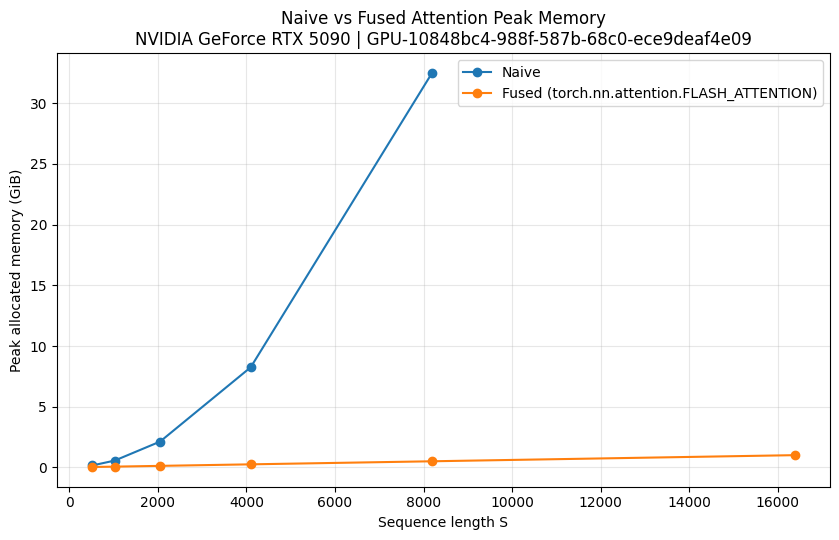

Saved /content/hw2_5_artifacts/figures/part_d_naive_vs_fused_memory.png


In [ ]:
# Combined memory comparison for additional visual context.
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for name, df in [("Naive", naive_coarse), (f"Fused ({FUSED_BACKEND_NAME})", fused_coarse)]:
    d = df[df["success"] == True].sort_values("sequence_length")
    ax.plot(d["sequence_length"], d["peak_memory_GiB"], marker="o", label=name)
ax.set_xlabel("Sequence length S")
ax.set_ylabel("Peak allocated memory (GiB)")
ax.set_title(f"Naive vs Fused Attention Peak Memory\n{GPU_NAME} | {GPU_UUID}")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
p = FIG_DIR / "part_d_naive_vs_fused_memory.png"
fig.savefig(p, dpi=180)
plt.show()
log(f"Saved {p}")